In [3]:
### import librarys ######
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn import linear_model
from sklearn.metrics import mean_squared_error , mean_absolute_error
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns 
import joblib

In [4]:
data = pd.read_csv("Documents\house.csv")

In [5]:
### Data Type ###
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Neighborhood  1460 non-null   object
 1   OverallQual   1460 non-null   int64 
 2   YearBuilt     1460 non-null   int64 
 3   YearRemodAdd  1460 non-null   int64 
 4   TotalBsmtSF   1460 non-null   int64 
 5   CentralAir    1460 non-null   object
 6   GrLivArea     1460 non-null   int64 
 7   BedroomAbvGr  1460 non-null   int64 
 8   KitchenQual   1460 non-null   object
 9   TotRmsAbvGrd  1460 non-null   int64 
 10  Fireplaces    1460 non-null   int64 
 11  GarageCars    1460 non-null   int64 
 12  GarageArea    1460 non-null   int64 
 13  SalePrice     1460 non-null   int64 
dtypes: int64(11), object(3)
memory usage: 159.8+ KB


In [6]:
data

,Neighborhood,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,CentralAir,GrLivArea,BedroomAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,SalePrice
0,CollgCr,7,2003,2003,856,Y,1710,3,Gd,8,0,2,548,208500
1,Veenker,6,1976,1976,1262,Y,1262,3,TA,6,1,2,460,181500
2,CollgCr,7,2001,2002,920,Y,1786,3,Gd,6,1,2,608,223500
3,Crawfor,7,1915,1970,756,Y,1717,3,Gd,7,1,3,642,140000
4,NoRidge,8,2000,2000,1145,Y,2198,4,Gd,9,1,3,836,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,Gilbert,6,1999,2000,953,Y,1647,3,TA,7,1,2,460,175000
1456,NWAmes,6,1978,1988,1542,Y,2073,3,TA,7,2,2,500,210000
1457,Crawfor,7,1941,2006,1152,Y,2340,4,Gd,9,2,1,252,266500
1458,NAmes,5,1950,1996,1078,Y,1078,2,Gd,5,0,1,240,142125


In [7]:
    ### Drop straing coulmn ###
data = data.drop("Neighborhood",axis=1)
data = data.drop("CentralAir",axis=1)          
data = data.drop("KitchenQual",axis=1)

In [8]:
data

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,SalePrice
0,7,2003,2003,856,1710,3,8,0,2,548,208500
1,6,1976,1976,1262,1262,3,6,1,2,460,181500
2,7,2001,2002,920,1786,3,6,1,2,608,223500
3,7,1915,1970,756,1717,3,7,1,3,642,140000
4,8,2000,2000,1145,2198,4,9,1,3,836,250000
...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,2000,953,1647,3,7,1,2,460,175000
1456,6,1978,1988,1542,2073,3,7,2,2,500,210000
1457,7,1941,2006,1152,2340,4,9,2,1,252,266500
1458,5,1950,1996,1078,1078,2,5,0,1,240,142125


In [9]:
 #### correlation #########
data.corr()

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,SalePrice
OverallQual,1.000000,0.572323,0.550684,0.537808,0.593007,0.101676,0.427452,0.396765,0.600671,0.562022,0.790982
YearBuilt,0.572323,1.000000,0.592855,0.391452,0.199010,-0.070651,0.095589,0.147716,0.537850,0.478954,0.522897
YearRemodAdd,0.550684,0.592855,1.000000,0.291066,0.287389,-0.040581,0.191740,0.112581,0.420622,0.371600,0.507101
TotalBsmtSF,0.537808,0.391452,0.291066,1.000000,0.454868,0.050450,0.285573,0.339519,0.434585,0.486665,0.613581
GrLivArea,0.593007,0.199010,0.287389,0.454868,1.000000,0.521270,0.825489,0.461679,0.467247,0.468997,0.708624
BedroomAbvGr,0.101676,-0.070651,-0.040581,0.050450,0.521270,1.000000,0.676620,0.107570,0.086106,0.065253,0.168213
TotRmsAbvGrd,0.427452,0.095589,0.191740,0.285573,0.825489,0.676620,1.000000,0.326114,0.362289,0.337822,0.533723
Fireplaces,0.396765,0.147716,0.112581,0.339519,0.461679,0.107570,0.326114,1.000000,0.300789,0.269141,0.466929
GarageCars,0.600671,0.537850,0.420622,0.434585,0.467247,0.086106,0.362289,0.300789,1.000000,0.882475,0.640409
GarageArea,0.562022,0.478954,0.371600,0.486665,0.468997,0.065253,0.337822,0.269141,0.882475,1.000000,0.623431


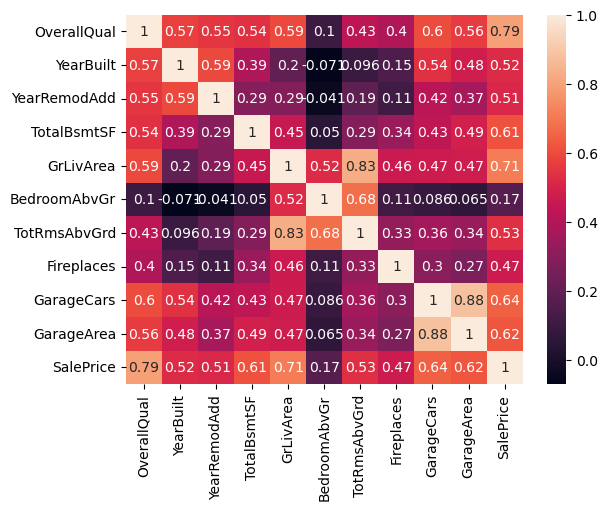

In [10]:
### Heatmap correlation ###
sns.heatmap(data.corr(),annot = True)
plt.show()

In [11]:
data

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea,SalePrice
0,7,2003,2003,856,1710,3,8,0,2,548,208500
1,6,1976,1976,1262,1262,3,6,1,2,460,181500
2,7,2001,2002,920,1786,3,6,1,2,608,223500
3,7,1915,1970,756,1717,3,7,1,3,642,140000
4,8,2000,2000,1145,2198,4,9,1,3,836,250000
...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,2000,953,1647,3,7,1,2,460,175000
1456,6,1978,1988,1542,2073,3,7,2,2,500,210000
1457,7,1941,2006,1152,2340,4,9,2,1,252,266500
1458,5,1950,1996,1078,1078,2,5,0,1,240,142125


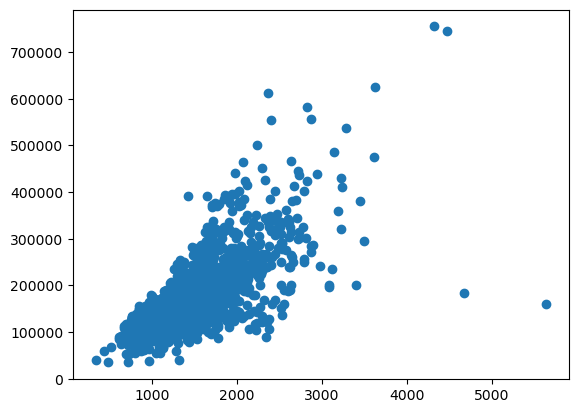

In [12]:
### Scatter ###
plt.scatter(data.GrLivArea,data.SalePrice)
plt.show()

In [13]:
#### Larg Area ####
data.GrLivArea.min()

334

In [14]:
### Small Area ###
data.GrLivArea.max()

5642

In [15]:
### Expensive Price ###
data.SalePrice.min()

34900

In [16]:
### Cheap Price ###
data.SalePrice.max()

755000

In [17]:
### Divide Feature ###
Feature = data.drop("SalePrice", axis = 1)

In [18]:
Feature

,OverallQual,YearBuilt,YearRemodAdd,TotalBsmtSF,GrLivArea,BedroomAbvGr,TotRmsAbvGrd,Fireplaces,GarageCars,GarageArea
0,7,2003,2003,856,1710,3,8,0,2,548
1,6,1976,1976,1262,1262,3,6,1,2,460
2,7,2001,2002,920,1786,3,6,1,2,608
3,7,1915,1970,756,1717,3,7,1,3,642
4,8,2000,2000,1145,2198,4,9,1,3,836
...,...,...,...,...,...,...,...,...,...,...
1455,6,1999,2000,953,1647,3,7,1,2,460
1456,6,1978,1988,1542,2073,3,7,2,2,500
1457,7,1941,2006,1152,2340,4,9,2,1,252
1458,5,1950,1996,1078,1078,2,5,0,1,240


In [19]:
### Divide Price ###
Price = data.SalePrice

In [20]:
Price

0       208500
1       181500
2       223500
3       140000
4       250000
         ...  
1455    175000
1456    210000
1457    266500
1458    142125
1459    147500
Name: SalePrice, Length: 1460, dtype: int64

In [21]:
###Creat Model ###
model = linear_model.LinearRegression()

In [22]:
### Train Model
model.fit(Feature,Price)

LinearRegression()

In [23]:
### Pcredict Price ###
predictions = model.predict(Feature)

In [24]:
predictions

array([214557.53634638, 173786.87100965, 223587.59847007, ...,
       237850.31247492, 124881.8230665 , 128481.77053369])

In [25]:
### Price ###
Price.values

array([208500, 181500, 223500, ..., 266500, 142125, 147500])

In [26]:
### M ###
model.coef_

array([17391.28875028,   245.95048144,   281.94110066,    26.73533178,
          47.5646602 , -8607.22074539,  3266.51664182,  9734.01223273,
        8011.21266208,    21.28249715])

In [27]:
### B ###
model.intercept_

np.float64(-1096765.0414456206)

In [28]:
### AVG error
mean_absolute_error(Price,predictions)

23737.620182955663

In [29]:
###add new data ###
dataa = pd.read_excel("Documents/housee.xlsx")

In [30]:
newdata = model.predict(dataa) 

In [31]:
newdata

array([214557.53634638, 173786.87100965, 223587.59847007, 197748.52008735,
       279837.09538319, 162870.98532832, 262528.30393023, 238345.35604198,
       213889.59889021, 125556.67568101, 111464.96531711, 321083.7860845 ,
       105030.55579239, 243899.52468388, 159702.88751744, 153839.90216324])

In [32]:
### Save Model
joblib.dump(model,"HouseModel")

['HouseModel']